-----------

##### Name: Mathews Mathew Plathottam

##### Topic: Multiclass Classification

-------------------

### | Importing the Libraries

-------------

In [26]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report



Imported the required Python libraries to handle data, build ML pipelines, train models, evaluate performance, and visualize results.

-----------------

### | About the Dataset

--------------------

The **Iris dataset** is a well-known benchmark dataset used for **multiclass classification** in machine learning.

It contains **150 flower samples** from the genus Iris, divided equally into **three species**:

* Iris-setosa
* Iris-versicolor
* Iris-virginica

Each sample is described using **four numeric features** (measured in centimeters):

1. Sepal Length
2. Sepal Width
3. Petal Length
4. Petal Width

The target variable is `Species`, which has `three classes`, making it a standard `multiclass classification problem`. The dataset is widely used because it is clean, relatively small, and the classes are reasonably separable (especially setosa), allowing students to understand the full workflow of classification: preprocessing, train-test split, scaling, model training, and evaluation using confusion matrix and classification metrics.

-------

### | Loading the Dataset

-----------------

In [6]:
df = pd.read_csv("Iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


------------

### | Understanding Dataset

------------------

##### | Shape of the Dataset

In [7]:
df.shape

(150, 6)

Checked the number of rows and columns to understand dataset size and complexity.

##### | Checking the first 5 Values

In [8]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


* Displayed the first few records to understand what columns exist, their names, and how values look.

##### | Information of the Dataset

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


* Checked data types (numeric vs object), non-null counts, and memory usage.
* This is important to identify categorical columns and potential missing values.

In [13]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


* Generated statistical summary (mean, std, min, max, quartiles) for numeric columns to understand feature ranges and variation.

--------------------

### | Exploratory Data Analysis (EDA)

-------------------

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [15]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [16]:
df.isna().sum().sort_values(ascending=False)

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

* Identified which columns contain missing values and how many.
* This step is necessary because most ML algorithms cannot train properly if NaN values are present.

------------------

### | Data Visualization

-------------------

##### | Comparing Sepal Length and Sepal Width

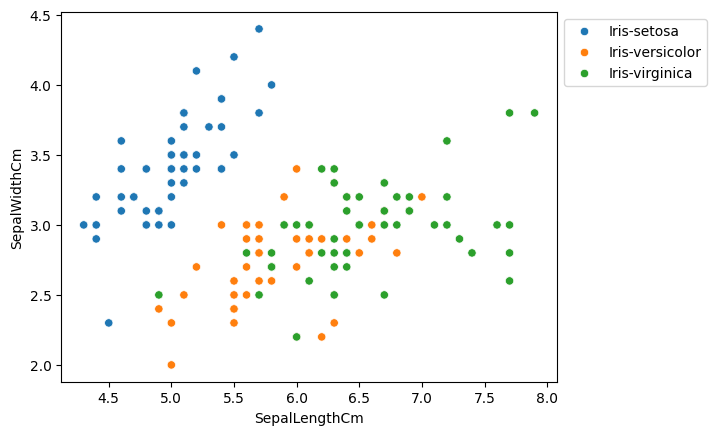

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm',
                hue='Species', data=df, )

# Placing Legend outside the Figure
plt.legend(bbox_to_anchor=(1, 1), loc=2)

plt.show()

##### | Comparing Petal Length and Petal Width

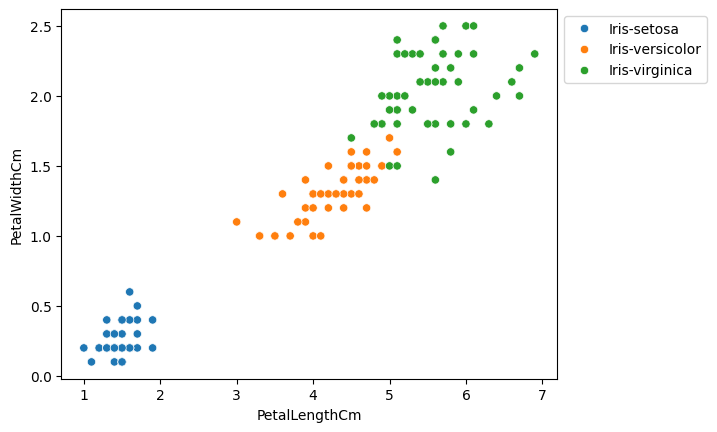

In [30]:
# importing packages
import seaborn as sns
import matplotlib.pyplot as plt


sns.scatterplot(x='PetalLengthCm', y='PetalWidthCm',
                hue='Species', data=df, )

# Placing Legend outside the Figure
plt.legend(bbox_to_anchor=(1, 1), loc=2)

plt.show()

From the above plot, we can infer that:

* Species Setosa has smaller petal lengths and widths.
* Versicolor Species lies in the middle of the other two species in terms of petal length and width
* Species Virginica has the largest of petal lengths and widths.

---------

### | Clean columns + Set x and y

----------------

In [17]:
df.columns = df.columns.str.strip()

In [18]:
# Drop Id if present
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

X = df.drop(columns=["Species"])
y = df["Species"]

y.value_counts()


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

-----------------------

### | Setting up Train/Test Split

----------------

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

---------------------

### | Scale features (needed for LR, KNN, SVC)

---------------------

In [21]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

----------------------

### | Training 4 models

---------------------

In [22]:
# Logistic Regression (multiclass)
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_sc, y_train)
pred_log = log_model.predict(X_test_sc)

# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_sc, y_train)
pred_knn = knn_model.predict(X_test_sc)

# SVC
svc_model = SVC(kernel="rbf")
svc_model.fit(X_train_sc, y_train)
pred_svc = svc_model.predict(X_test_sc)

# Random Forest (no scaling)
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)

-------------------

### | Compare results (Accuracy + F1)

------------------

In [23]:
def multiclass_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1_macro": f1_score(y_true, y_pred, average="macro")
    }


In [24]:
results = pd.DataFrame([
    multiclass_metrics(y_test, pred_log, "Logistic Regression"),
    multiclass_metrics(y_test, pred_rf, "Random Forest"),
    multiclass_metrics(y_test, pred_knn, "KNN"),
    multiclass_metrics(y_test, pred_svc, "SVC"),
]).sort_values("F1_macro", ascending=False)

results

,Model,Accuracy,F1_macro
3,SVC,0.966667,0.966583
0,Logistic Regression,0.933333,0.933333
2,KNN,0.933333,0.932660
1,Random Forest,0.900000,0.899749


-------------------------

### | Best model + Confusion Matrix + Classification Report

-------------------

In [27]:
best_model = results.iloc[0]["Model"]
print("Best model:", best_model)

pred_map = {
    "Logistic Regression": pred_log,
    "Random Forest": pred_rf,
    "KNN": pred_knn,
    "SVC": pred_svc
}
best_pred = pred_map[best_model]

print(classification_report(y_test, best_pred))

Best model: SVC
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



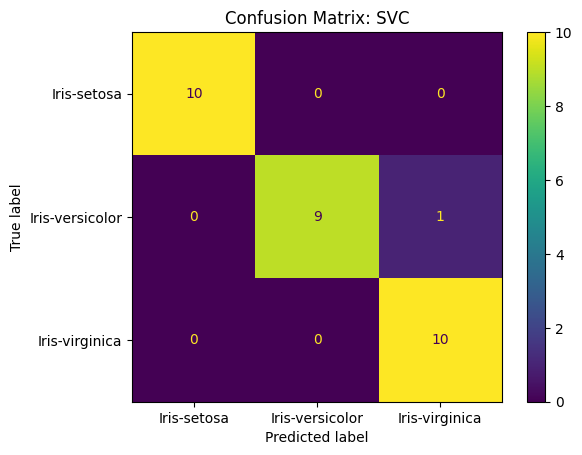

In [28]:
cm = confusion_matrix(y_test, best_pred, labels=y.unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y.unique())
disp.plot()
plt.title(f"Confusion Matrix: {best_model}")
plt.grid(False)
plt.show()

--------------------------